# ✈ Standby Crew Demand Predictor ✈

### Core Idea

-  Keeping reserve/standby crew at the airport is expensive, but not having enough causes massive flight cancellations when someone calls in sick. This project builds a simple Python tool that looks at the day of the week, flight volume, and historical sickness trends to predict how many standby crew members will actually be needed tomorrow.

### Generating Synthetic Data

We will create a synthetic dataset. This dataset will include columns for `date`, `day_of_week`, `flight_volume`, `historical_sickness_rate`, and `standby_crew_needed`.

In [1]:
import pandas as pd
import numpy as np

# Set a seed for reproducibility
np.random.seed(42)

# Generate dates for a year
dates = pd.date_range(start='2023-01-01', periods=365, freq='D')

# Generate synthetic data
data = {
    'date': dates,
    'day_of_week': dates.dayofweek, # Monday=0, Sunday=6
    'flight_volume': np.random.randint(100, 500, size=len(dates)),
    'historical_sickness_rate': np.random.uniform(0.01, 0.05, size=len(dates))
}

df = pd.DataFrame(data)

# Introduce some seasonality or trends for standby crew needed
# Higher demand on weekends and with higher flight volume/sickness rates
df['standby_crew_needed'] = (df['flight_volume'] * df['historical_sickness_rate'] * 5 +
                           (df['day_of_week'].isin([5, 6])) * 10 + # Weekends
                           np.random.randint(0, 5, size=len(dates))).astype(int)

# Ensure standby crew needed is not negative
df['standby_crew_needed'] = df['standby_crew_needed'].apply(lambda x: max(0, x))

print("Synthetic data generated successfully!")
display(df.head())

Synthetic data generated successfully!


,date,day_of_week,flight_volume,historical_sickness_rate,standby_crew_needed
0,2023-01-01,6,202,0.028798,42
1,2023-01-02,0,448,0.021182,48
2,2023-01-03,1,370,0.045340,84
3,2023-01-04,2,206,0.039909,41
4,2023-01-05,3,171,0.048123,42


### Data Cleaning and Preprocessing

First, let's check for any missing values in our synthetic dataset. Although we already generated it, it's good practice to ensure data integrity.

In [2]:
print("Missing values per column:")
display(df.isnull().sum())

print("\nData types:")
display(df.info())

Missing values per column:


,0
date,0
day_of_week,0
flight_volume,0
historical_sickness_rate,0
standby_crew_needed,0



Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      365 non-null    datetime64[ns]
 1   day_of_week               365 non-null    int32         
 2   flight_volume             365 non-null    int64         
 3   historical_sickness_rate  365 non-null    float64       
 4   standby_crew_needed       365 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(2)
memory usage: 13.0 KB


None

Next, we'll convert the `day_of_week` into a categorical format suitable for machine learning models using one-hot encoding. We'll also drop the original `date` column as we've extracted `day_of_week` from it, and directly using the date might introduce too much specificity or require more complex time-series modeling than planned before.

In [3]:
df = pd.get_dummies(df, columns=['day_of_week'], prefix='day')
df = df.drop('date', axis=1)

print("DataFrame after one-hot encoding 'day_of_week' and dropping 'date':")
display(df.head())

DataFrame after one-hot encoding 'day_of_week' and dropping 'date':


,flight_volume,historical_sickness_rate,standby_crew_needed,day_0,day_1,day_2,day_3,day_4,day_5,day_6
0,202,0.028798,42,False,False,False,False,False,False,True
1,448,0.021182,48,True,False,False,False,False,False,False
2,370,0.045340,84,False,True,False,False,False,False,False
3,206,0.039909,41,False,False,True,False,False,False,False
4,171,0.048123,42,False,False,False,True,False,False,False


### Exploratory Data Analysis (EDA)

Next, let's visualize the distributions of our key features and the target variable (`standby_crew_needed`) to understand their characteristics and potential relationships.

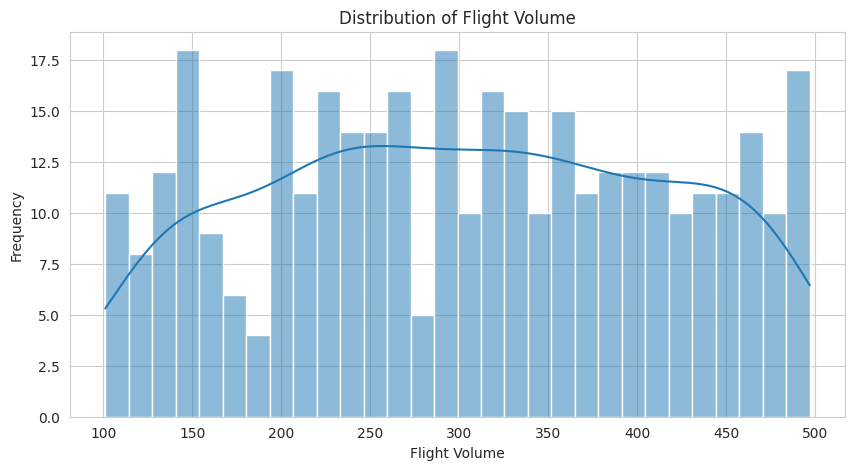

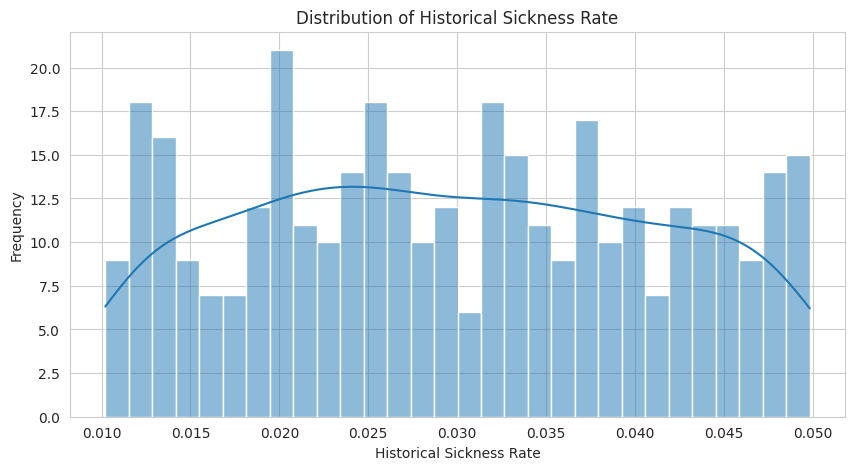

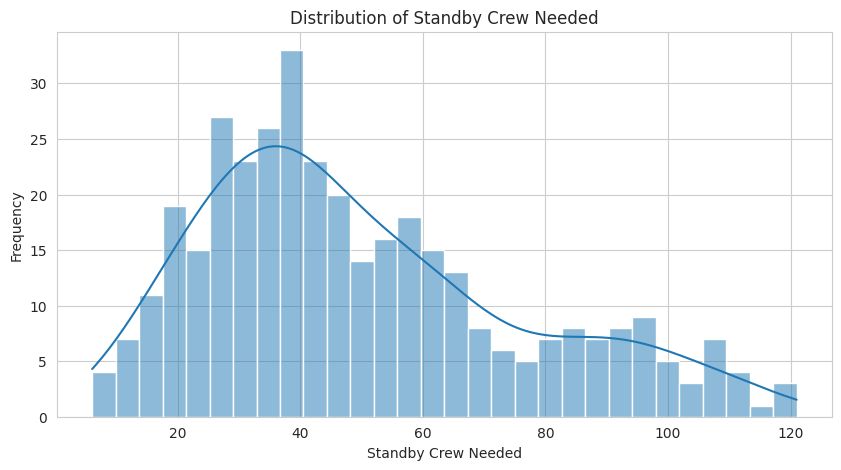

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Plot distribution of flight_volume
plt.figure(figsize=(10, 5))
sns.histplot(df['flight_volume'], kde=True, bins=30)
plt.title('Distribution of Flight Volume')
plt.xlabel('Flight Volume')
plt.ylabel('Frequency')
plt.show()

# Plot distribution of historical_sickness_rate
plt.figure(figsize=(10, 5))
sns.histplot(df['historical_sickness_rate'], kde=True, bins=30)
plt.title('Distribution of Historical Sickness Rate')
plt.xlabel('Historical Sickness Rate')
plt.ylabel('Frequency')
plt.show()

# Plot distribution of standby_crew_needed
plt.figure(figsize=(10, 5))
sns.histplot(df['standby_crew_needed'], kde=True, bins=30)
plt.title('Distribution of Standby Crew Needed')
plt.xlabel('Standby Crew Needed')
plt.ylabel('Frequency')
plt.show()

Up next, let's look at the relationship between `standby_crew_needed` and our features, including the day of the week, flight volume, and historical sickness rate. We use a correlation matrix and scatter plots here.

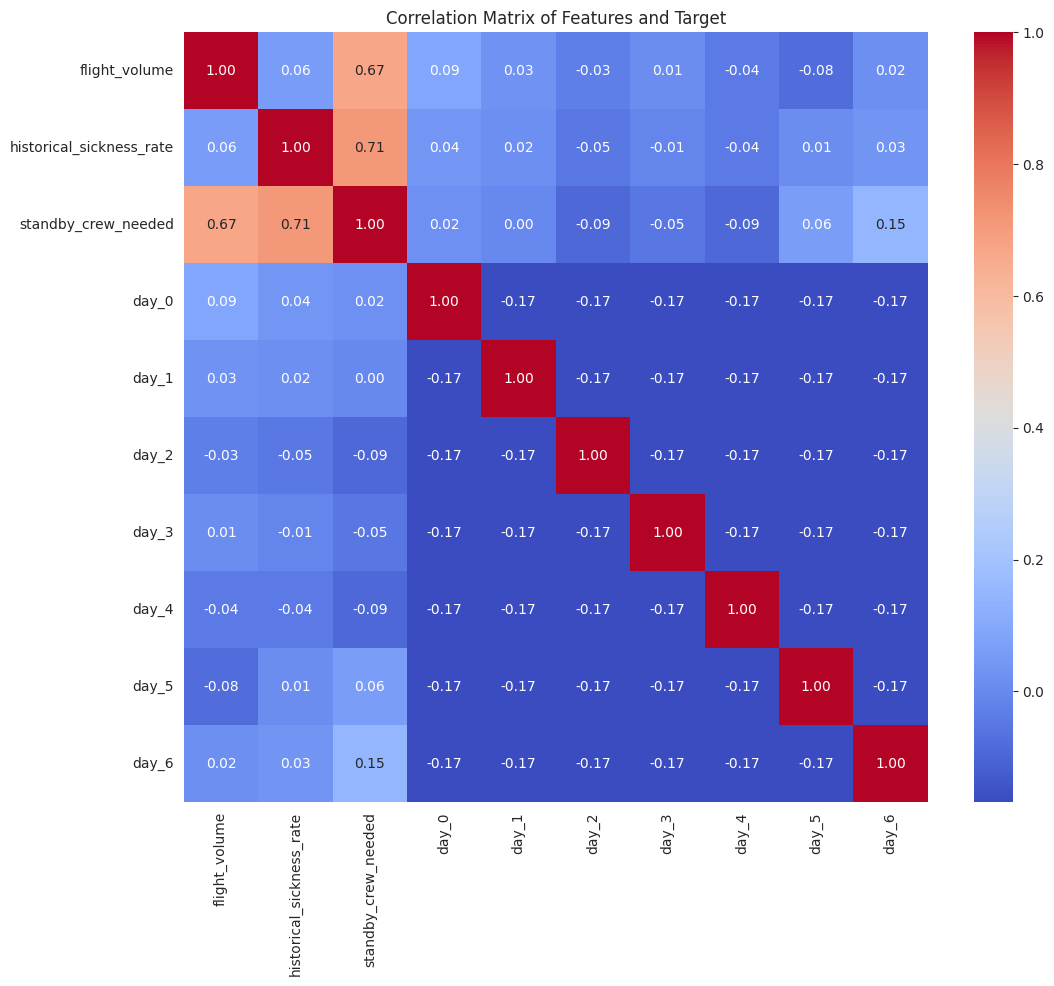

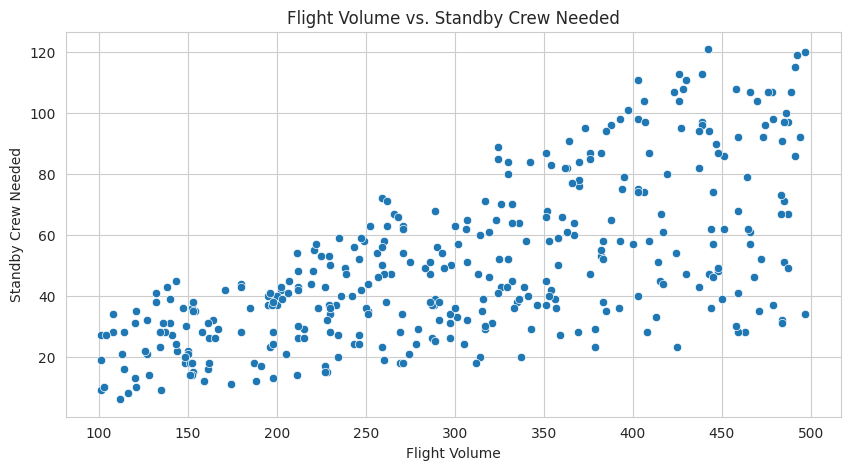

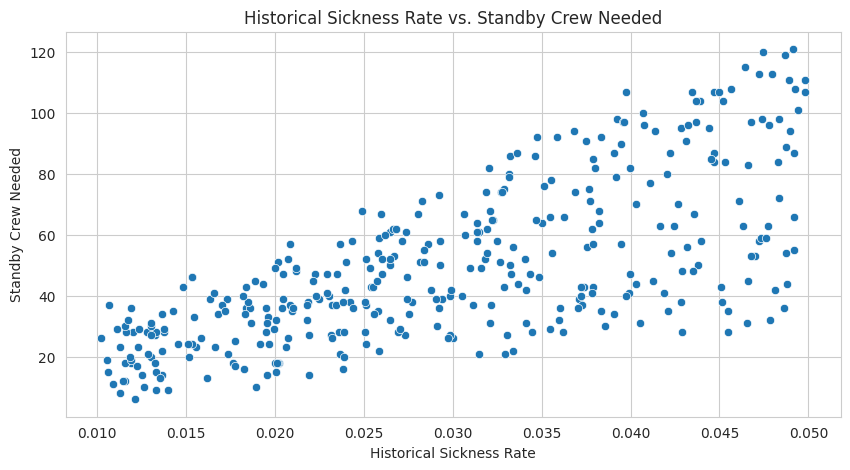

In [5]:
# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features and Target')
plt.show()

# Scatter plot of flight_volume vs. standby_crew_needed
plt.figure(figsize=(10, 5))
sns.scatterplot(x='flight_volume', y='standby_crew_needed', data=df)
plt.title('Flight Volume vs. Standby Crew Needed')
plt.xlabel('Flight Volume')
plt.ylabel('Standby Crew Needed')
plt.show()

# Scatter plot of historical_sickness_rate vs. standby_crew_needed
plt.figure(figsize=(10, 5))
sns.scatterplot(x='historical_sickness_rate', y='standby_crew_needed', data=df)
plt.title('Historical Sickness Rate vs. Standby Crew Needed')
plt.xlabel('Historical Sickness Rate')
plt.ylabel('Standby Crew Needed')
plt.show()

### Model Training

Now that we have preprocessed our data and explored its characteristics, let's train a machine learning model to predict the `standby_crew_needed`. We'll use a Random Forest Regressor, which is suitable for this type of problem.

First, we need to split our data into features (X) and the target variable (y), and then divide it into training and testing sets.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop('standby_crew_needed', axis=1)
y = df['standby_crew_needed']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (292, 9), (292,)
Testing set shape: (73, 9), (73,)


Next, we'll initialize and train our Random Forest Regressor model.

In [7]:
# Initialize the Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully!")

Random Forest Regressor model trained successfully!


### Model Evaluation

After training, it's important to evaluate the model's performance on unseen data (the test set). We'll use common regression metrics, including Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared ($R^2$).

Mean Absolute Error (MAE): 3.22
Mean Squared Error (MSE): 16.40
Root Mean Squared Error (RMSE): 4.05
R-squared (R2): 0.98


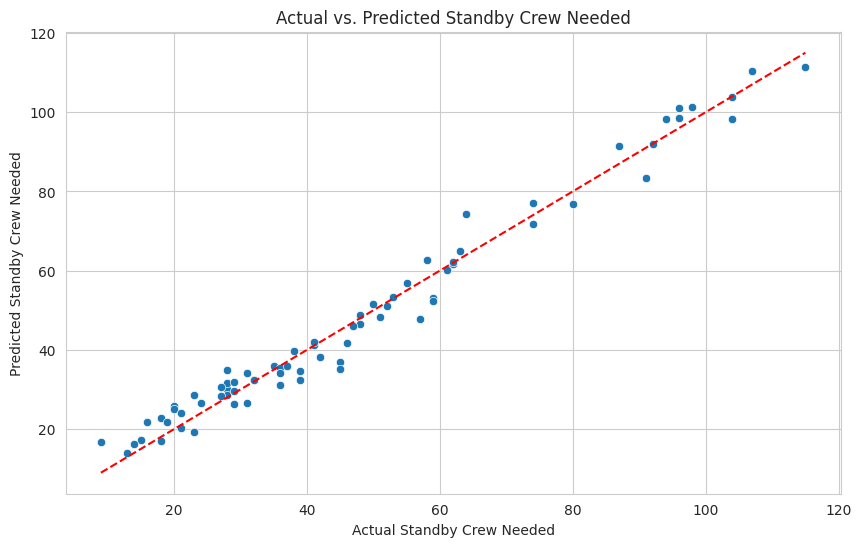

In [8]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Visualize actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Standby Crew Needed")
plt.ylabel("Predicted Standby Crew Needed")
plt.title("Actual vs. Predicted Standby Crew Needed")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Ideal line
plt.show()

### Prediction

Now that we have a trained and evaluated model, we can use it to predict the number of standby crew members needed for a new day. Let's create a scenario for 'tomorrow' and use our model to make a prediction.

In [9]:
# Create a hypothetical 'tomorrow' for prediction
# Let's say tomorrow is a Tuesday (day_of_week=1), with moderate flight volume and average sickness rate

# Note: The order of columns in this new data must match the training data (X).
# The columns are: 'flight_volume', 'historical_sickness_rate', 'day_0'...'day_6'

# Example for a Tuesday (day_1 is True, others are False)
new_data = {
    'flight_volume': [350],  # Example flight volume
    'historical_sickness_rate': [0.035], # Example sickness rate
    'day_0': [False], # Monday
    'day_1': [True],  # Tuesday
    'day_2': [False], # Wednesday
    'day_3': [False], # Thursday
    'day_4': [False], # Friday
    'day_5': [False], # Saturday
    'day_6': [False]  # Sunday
}

# Create a DataFrame for the new data
new_df = pd.DataFrame(new_data)

# Ensure column order matches X_train
new_df = new_df[X_train.columns]

# Make a prediction
predicted_crew = model.predict(new_df)

print(f"Predicted standby crew needed for tomorrow: {int(round(predicted_crew[0]))}")

Predicted standby crew needed for tomorrow: 67
